# 第 13 章 DDPG 算法
## 13.1 简介
之前的章节介绍了基于策略梯度的算法 REINFORCE、Actor-Critic 以及两个改进算法——TRPO 和 PPO。

这类算法有一个共同的特点：它们都是**在线策略算法**，这意味着它们的样本效率（sample efficiency）比较低。

- DQN 算法，DQN 算法直接估计最优函数 Q，**可以做到离线策略学习**，但是它**只能处理动作空间有限**的环境，这是因为它需要从所有动作中挑选一个 $Q$ 值最大的动作。
- 如果动作个数是无限的，虽然可以像 8.3 节一样，将动作空间离散化，但这比较粗糙，无法精细控制。

那有没有办法可以用类似的思想来**处理动作空间无限**的环境并且使用的是**离线策略算法**呢？

- 深度确定性策略梯度（deep deterministic policy gradient，DDPG）算法就是如此，它构造一个**确定性策略**，用梯度上升的方法来最大化值。DDPG 也属于一种 Actor-Critic 算法。
- 之前学习的 REINFORCE、TRPO 和 PPO **学习随机性策略**，而本章的 DDPG 则**学习一个确定性策略**。

### 13.2 DDPG 算法

之前我们学习的策略是随机性的，可以表示为 ；

而如果策略是**确定性**的，则可以记为 

与策略梯度定理类似，可以推导出 *确定性策略梯度定理* （deterministic policy gradient theorem）：

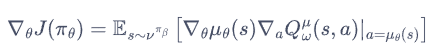

- $ \pi^\beta $ 是用来收集数据的行为策略。
    - 假设现在已经有函数 $ Q(s,a) $，给定一个状态 $ s $，但由于现在动作空间是无限的，无法通过遍历所有动作来得到 $Q$ 值最大的动作，因此想用策略 $\mu$ 找到使 $Q(s,a)$ 值最大的动作 $ a $，即 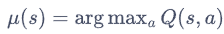。
- 此时，$ Q $ 就是 Critic，$ \mu $ 就是 Actor，这是一个 Actor-Critic 的框架，如图 13-1 所示。

那如何得到这个 $\mu$ 呢？

首先用 $Q$ 对 $\mu_\theta$ 求导 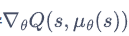，
其中会用到梯度的链式法则，先对 $a$ 求导，再对 $\theta$ 求导。

然后通过梯度上升的方法来最大化函数 $ Q$，得到 $Q$ 值最大的动作。
具体的推导过程可参见 13.5 节。

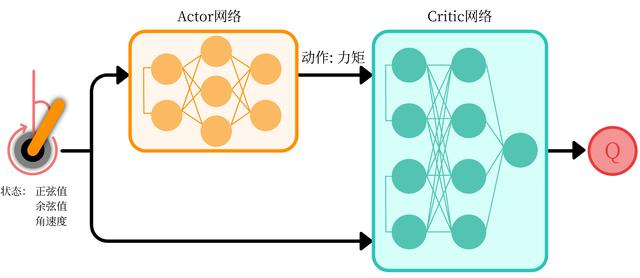

图13-1 DDPG 中的 Actor 网络和 Critic 网络，以倒立摆环境为例

下面我们来看一下 DDPG 算法的细节。

DDPG 要用到 4 个神经网络，
- 其中 Actor 和 Critic 各用一个网络，此外它们都各自有一个目标网络。

至于为什么需要目标网络，读者可以回到第 7 章去看 DQN 中的介绍。

- DDPG 中 Actor 也需要目标网络因为**目标网络也会被用来计算目标 $Q$ 值**。
- DDPG 中目标网络的更新与 DQN 中略有不同：
    - 在 DQN 中，每隔一段时间将 $Q$ 网络直接复制给目标 $Q$ 网络；
    - 在 DDPG 中，目标 $Q$ 网络的更新采取的是一种软更新的方式，即让目标 $Q$ 网络缓慢更新，逐渐接近 $Q$ 网络，其公式为：

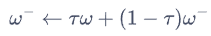

通常 $\tau$ 是一个比较小的数，当 $\tau=1$ 时，就和 DQN 的更新方式一致了, 目标 Actor 网络也使用这种软更新的方式。

另外，由于函数 $Q$ 存在 $Q$ 值过高估计的问题，DDPG 采用了 Double DQN 中的技术来更新 $Q$ 网络。

但是，由于 DDPG 采用的是**确定性策略**，它**本身的探索仍然十分有限**。

DQN 算法的探索主要由 $ \epsilon $-贪婪策略的行为策略产生。

同样作为一种离线策略的算法，DDPG 在行为策略上引入一个**随机噪声 $\mathcal{N}$ 来进行探索**


- 随机噪声可以用 $\mathcal{N}$ 来表示，用随机的网络参数 $\omega$ 和 $\theta$ 分别初始化 Critic 网络 $Q_{\omega}(s, a)$ 和 Actor 网络 $\mu_{\theta}(s)$
- 复制相同的参数：$\omega^{-} \leftarrow \omega, \theta^{-} \leftarrow \theta$，分别初始化目标网络 $Q_{\omega^{-}}$ 和 $\mu_{\theta^{-}}$
- 初始化经验回放池 $R$
- **for** 序列 $e = 1 \to E$ **do**:
    - 初始化随机过程 $\mathcal{N}$ 用于动作探索
    - 获取环境初始状态 $s_1$
    - **for** 时间步 $t = 1 \to T$ **do**:
        - 根据当前策略和噪声选择动作 $a_t = \mu_{\theta}(s_t) + \mathcal{N}$
        - 执行动作 $a_t$，获得奖励 $r_t$，环境状态变为 $s_{t+1}$
        - 将 $(s_t, a_t, r_t, s_{t+1})$ 存储进回放池 $R$
        - 从 $R$ 中采样 $N$ 个元组 $\{(s_i, a_i, r_i, s_{i+1})\}_{i=1,...,N}$
        - 对每个元组，用目标网络计算 $y_i = r_i + \gamma Q_{\omega^{-}}(s_{i+1}, \mu_{\theta^{-}}(s_{i+1}))$
        - 最小化目标损失 $L = \dfrac{1}{N}\sum_{i=1}^{N}(y_i - Q_{\omega}(s_i, a_i))^2$，以此更新当前 Critic 网络
        - 计算采样的策略梯度，以此更新当前 Actor 网络：
            $$
            \nabla_{\theta} J \approx \frac{1}{N}\sum_{i=1}^{N} \nabla_{\theta}\mu_{\theta}(s_i)\nabla_a Q_{\omega}(s_i, a)|_{a=\mu_{\theta}(s_i)}
            $$
        - 更新目标网络：
            $$
            \omega^{-} \leftarrow \tau \omega + (1-\tau)\omega^{-}
            $$
            $$
            \theta^{-} \leftarrow \tau \theta + (1-\tau)\theta^{-}
            $$

    - **end for**
- **end for**

### 13.3 DDPG 代码实践
以倒立摆环境为例，结合代码详细讲解 DDPG 的具体实现。


In [1]:
import random
import gym
import numpy as np
from tqdm import tqdm
import torch
from torch import nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import sys
sys.path.append('../') # 在上层目录下
import rl_utils

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


对于策略网络和价值网络，采用只有一层隐藏层的神经网络。

策略网络的输出层用正切函数（$y = tanh x$）作为激活函数，这是因为正切函数的值域是$[-1, 1]$，方便按比例调整成环境可以接受的动作范围。

在 DDPG 中处理的是**与连续动作交互的环境**，$Q$网络的**输入**是**状态和动作拼接后的向量**，$Q$网络的输出是一个值，表示该状态动作对的价值。

In [2]:
class PolicyNet(torch.nn.Module):
    def __init__(self, state_dim, hidden_dim, action_dim, action_bound):
        super(PolicyNet, self).__init__()
        self.fc1 = torch.nn.Linear(state_dim, hidden_dim)
        self.fc2 = torch.nn.Linear(hidden_dim, action_dim)
        self.action_bound = action_bound  # action_bound是环境可以接受的动作最大值

    def forward(self, x):
        x = F.relu(self.fc1(x))
        return torch.tanh(self.fc2(x)) * self.action_bound


class QValueNet(torch.nn.Module):
    def __init__(self, state_dim, hidden_dim, action_dim):
        super(QValueNet, self).__init__()
        self.fc1 = torch.nn.Linear(state_dim + action_dim, hidden_dim)
        self.fc2 = torch.nn.Linear(hidden_dim, hidden_dim)
        self.fc_out = torch.nn.Linear(hidden_dim, 1)

    def forward(self, x, a):
        cat = torch.cat([x, a], dim=1) # 拼接状态和动作, dim=1表示按列拼接
        x = F.relu(self.fc1(cat))
        x = F.relu(self.fc2(x))
        return self.fc_out(x)


接下来是 **DDPG 算法的主体部分**。

在用策略网络采取消动作的时候，为了更好地探索，**向动作中加入高斯噪声**。

在 DDPG 的原始论文中，添加的噪声符合**奥恩斯坦-乌伦贝克（Ornstein-Uhlenbeck, OU）随机过程**：

$$
\Delta x_t = \theta (\mu - x_{t-1}) + \sigma W
$$

- $\mu$ 是均值，$W$ 是符合布朗运动的随机噪声，$\theta$ 和 $\sigma$ 是比例参数。
- 当 $x(t-1)$ 偏离均值时，$x_t$ 的值会向均值靠拢。
- OU 随机过程的特点是在均值附近做出线性负反馈，并有额外的干扰项。
- OU 随机过程是与时间相关的，适用于有惯性的系统。

在 DDPG 的实际中，不少地方仅使用正态分布的噪声。这里只为简便起见，同样使用正态分布的噪声，感兴趣的读者可以自行改为 OU 随机过程并观察效果。


In [3]:
class DDPG:
    ''' DDPG算法 '''
    def __init__(self, state_dim, hidden_dim, action_dim, action_bound, sigma, actor_lr, critic_lr, tau, gamma, device):
        self.actor = PolicyNet(state_dim, hidden_dim, action_dim, action_bound).to(device)
        self.critic = QValueNet(state_dim, hidden_dim, action_dim).to(device)
        self.target_actor = PolicyNet(state_dim, hidden_dim, action_dim, action_bound).to(device)
        self.target_critic = QValueNet(state_dim, hidden_dim, action_dim).to(device)
        # 初始化目标价值网络并设置和价值网络相同的参数
        self.target_critic.load_state_dict(self.critic.state_dict())
        # 初始化目标策略网络并设置和策略相同的参数
        self.target_actor.load_state_dict(self.actor.state_dict())
        self.actor_optimizer = torch.optim.Adam(self.actor.parameters(), lr=actor_lr)
        self.critic_optimizer = torch.optim.Adam(self.critic.parameters(), lr=critic_lr)
        self.gamma = gamma
        self.sigma = sigma  # 高斯噪声的标准差,均值直接设为0
        self.tau = tau  # 目标网络软更新参数
        self.action_dim = action_dim
        self.device = device

    def take_action(self, state):
        state = torch.tensor([state], dtype=torch.float).to(self.device)
        action = self.actor(state).item()
        # 给动作添加噪声，增加探索
        action = action + self.sigma * np.random.randn(self.action_dim)
        return action

    def soft_update(self, net, target_net):
        for param_target, param in zip(target_net.parameters(), net.parameters()):
            param_target.data.copy_(param_target.data * (1.0 - self.tau) + param.data * self.tau)

    def update(self, transition_dict):
        states = torch.tensor(transition_dict['states'], dtype=torch.float).to(self.device)
        actions = torch.tensor(transition_dict['actions'], dtype=torch.float).view(-1, 1).to(self.device)
        rewards = torch.tensor(transition_dict['rewards'], dtype=torch.float).view(-1, 1).to(self.device)
        next_states = torch.tensor(transition_dict['next_states'], dtype=torch.float).to(self.device)
        dones = torch.tensor(transition_dict['dones'], dtype=torch.float).view(-1, 1).to(self.device)

        next_q_values = self.target_critic(next_states, self.target_actor(next_states))
        q_targets = rewards + self.gamma * next_q_values * (1 - dones)
        critic_loss = torch.mean(F.mse_loss(self.critic(states, actions), q_targets))
        self.critic_optimizer.zero_grad()
        critic_loss.backward()
        self.critic_optimizer.step()

        actor_loss = -torch.mean(self.critic(states, self.actor(states)))
        self.actor_optimizer.zero_grad()
        actor_loss.backward()
        self.actor_optimizer.step()

        self.soft_update(self.actor, self.target_actor)  # 软更新策略网络
        self.soft_update(self.critic, self.target_critic)  # 软更新价值网络

In [4]:
actor_lr = 3e-4
critic_lr = 3e-3
num_episodes = 200
hidden_dim = 64
gamma = 0.98
tau = 0.005  # 软更新参数
buffer_size = 10000
minimal_size = 1000
batch_size = 64
sigma = 0.01  # 高斯噪声标准差
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

env_name = 'Pendulum-v1'
env = gym.make(env_name)
random.seed(0)
np.random.seed(0)
env.seed(0)
torch.manual_seed(0)
replay_buffer = rl_utils.ReplayBuffer(buffer_size)
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.shape[0]
action_bound = env.action_space.high[0]  # 动作最大值
agent = DDPG(state_dim, hidden_dim, action_dim, action_bound, sigma, actor_lr, critic_lr, tau, gamma, device)

return_list = rl_utils.train_off_policy_agent(env, agent, num_episodes, replay_buffer, minimal_size, batch_size)

Iteration 0:   0%|          | 0/20 [00:00<?, ?it/s]C:\Users\10240\AppData\Local\Temp\ipykernel_71192\2313165118.py:21: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:257.)
  state = torch.tensor([state], dtype=torch.float).to(self.device)
Iteration 9: 100%|██████████| 20/20 [00:27<00:00,  1.39s/it, episode=200, return=-159.242]


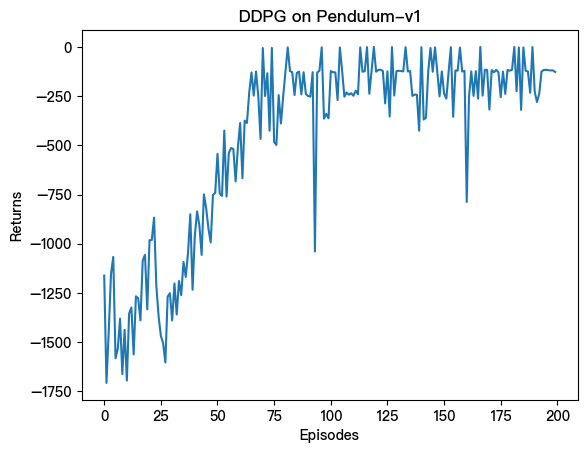

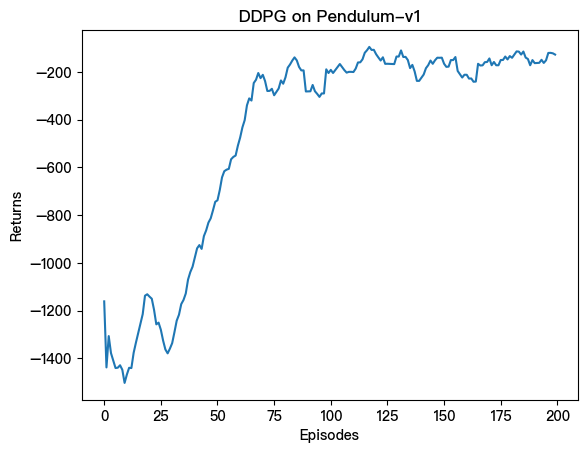

In [5]:
episodes_list = list(range(len(return_list)))
plt.plot(episodes_list, return_list)
plt.xlabel('Episodes')
plt.ylabel('Returns')
plt.title('DDPG on {}'.format(env_name))
plt.show()

mv_return = rl_utils.moving_average(return_list, 9)
plt.plot(episodes_list, mv_return)
plt.xlabel('Episodes')
plt.ylabel('Returns')
plt.title('DDPG on {}'.format(env_name))
plt.show()

本章讲解了深度确定性策略梯度算法（DDPG），它是面向**连续动作空间**的**深度确定性策略训练**的典型算法。

相比于它的先期工作，即确定性梯度算法（DPG），DDPG 加入了**目标网络和软更新**的方法，这对深度模型构建的价值网络和策略网络的稳定学习起到了关键的作用。

DDPG 算法也被引入了多智能体强化学习领域，催生了 MADDPG 算法。